# IDS Feature Selection & Hyperparameter Optimisation
## COMP2024 Coursework - Data Cleaning

In [1]:
#Importing dependancies 
import pandas as pd
import numpy as np
import os

## 1. Load & Merge All CSVs

In [2]:
#Loading all CSVs and making them a single dataframe
DATA_DIR = "Dataset_Raw/"

os.listdir(DATA_DIR)

thursday_afternoon = pd.read_csv(DATA_DIR + "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
monday = pd.read_csv(DATA_DIR + "Monday-WorkingHours.pcap_ISCX.csv")
friday_morning = pd.read_csv(DATA_DIR + "Friday-WorkingHours-Morning.pcap_ISCX.csv")
friday_afternoon_portscan = pd.read_csv(DATA_DIR + "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
friday_afternoon_ddos = pd.read_csv(DATA_DIR + "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
tuesday = pd.read_csv(DATA_DIR + "Tuesday-WorkingHours.pcap_ISCX.csv")
wednesday = pd.read_csv(DATA_DIR + "Wednesday-workingHours.pcap_ISCX.csv")
thursday_morning = pd.read_csv(DATA_DIR + "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")

df = pd.concat([thursday_afternoon, monday, friday_morning, friday_afternoon_portscan, friday_afternoon_ddos, tuesday, wednesday, thursday_morning], ignore_index=True)

## 2. Initial Exploration

In [3]:
#Checking shape, dtype and printing the first few columns

print(df.shape)
print(df.dtypes)
print(df.head(20))

(2830743, 79)
 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                             str
Length: 79, dtype: object
     Destination Port   Flow Duration   Total Fwd Packets  \
0                  22             166                   1   
1               60148              83                   1   
2                 123           99947                   1   
3                 123           37017                   1   
4                   0       111161336                 147   
5                 123           38407                   1   
6                 443          188867                   9   
7                 443          213931      

In [4]:
#Checking the class distribution of Label

df[" Label"].value_counts()

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

## 3. Data Cleaning

In [5]:
#Stripping whitespace from columns
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.strip()
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [6]:
# Rremoving Duplicate Rows
rows_before = len(df)
df.drop_duplicates(keep='first', inplace=True)

print(f'Duplicate rows removed: {rows_before - len(df):,}')
print(f'Remaining rows: {len(df):,}')

# Removing Duplicate Columns
cols_before = df.shape[1]
identical_cols = []
cols = df.columns.tolist()
seen = []
for i, c1 in enumerate(cols):
    for c2 in cols[i+1:]:
        if c2 not in seen and df[c1].equals(df[c2]):
            identical_cols.append(c2)
            seen.append(c2)

print(f'Identical columns found and removed: {identical_cols}')
df.drop(columns=identical_cols, inplace=True)
print(f'Columns: {cols_before} → {df.shape[1]}')

Duplicate rows removed: 308,381
Remaining rows: 2,522,362
Identical columns found and removed: ['Subflow Fwd Packets', 'Subflow Bwd Packets', 'SYN Flag Count', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'CWE Flag Count', 'Fwd Header Length.1']
Columns: 79 → 67


In [7]:
# Replace Infinity values with NaN 

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
print('Infinity values per column (non-zero only):')
print(inf_counts[inf_counts > 0])
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

Infinity values per column (non-zero only):
Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [8]:
# Handle NaN Values 

# Analyse NaN impact per class before deciding (so we dont remove classes with 1 or 2 NaN values)
nan_per_class = df.groupby('Label').apply(lambda x: x.isnull().any(axis=1).sum())
nan_pct_per_class = (nan_per_class / df['Label'].value_counts() * 100).round(2)
print('NaN row impact per attack class (%):')
print(nan_pct_per_class)

# Only drop rows where >50% of columns are NaN (truly corrupt rows)
before = len(df)
df.dropna(thresh=int(0.5 * df.shape[1]), inplace=True)
print(f'\nRows dropped (>50% NaN): {before - len(df):,}')

# Impute remaining NaN with column median
numeric_cols = df.select_dtypes(include=[np.number]).columns
nan_remaining = df[numeric_cols].isnull().sum().sum()
print(f'Remaining NaN values to impute: {nan_remaining:,}')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f'NaN after imputation: {df.isnull().sum().sum()}')

NaN row impact per attack class (%):
Label
BENIGN                        0.07
Bot                           0.26
DDoS                          0.00
DoS GoldenEye                 0.00
DoS Hulk                      0.00
DoS Slowhttptest              0.00
DoS slowloris                 0.00
FTP-Patator                   0.03
Heartbleed                    0.00
Infiltration                  0.00
PortScan                      0.14
SSH-Patator                   0.00
Web Attack � Brute Force      0.00
Web Attack � Sql Injection    0.00
Web Attack � XSS              0.00
dtype: float64

Rows dropped (>50% NaN): 0
Remaining NaN values to impute: 3,128
NaN after imputation: 0


In [9]:
# Remove Zero-Variance Columns 

zero_var_cols = [c for c in numeric_cols if df[c].nunique() <= 1]
print(f'Zero-variance columns removed: {zero_var_cols}')
df.drop(columns=zero_var_cols, inplace=True)
print(f'Shape after removal: {df.shape}')

Zero-variance columns removed: ['Bwd PSH Flags']
Shape after removal: (2522362, 66)


In [10]:
# Clip Negative Values to 0

numeric_cols = df.select_dtypes(include=[np.number]).columns
neg_counts = (df[numeric_cols] < 0).sum()
print('Columns with negative values (non-zero only):')
print(neg_counts[neg_counts > 0])
df[numeric_cols] = df[numeric_cols].clip(lower=0)
print('\nAll negative values clipped to 0.')

Columns with negative values (non-zero only):
Flow Duration                  107
Flow Bytes/s                    78
Flow Packets/s                 107
Flow IAT Mean                  107
Flow IAT Max                   107
Flow IAT Min                  2881
Fwd IAT Min                     17
Fwd Header Length               35
Bwd Header Length               22
Init_Win_bytes_forward      911027
Init_Win_bytes_backward    1216341
min_seg_size_forward            35
dtype: int64

All negative values clipped to 0.


## 5. Exploratory Data Analysis (EDA)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
OUTPUT_DIR = "Dataset_Cleaned/"


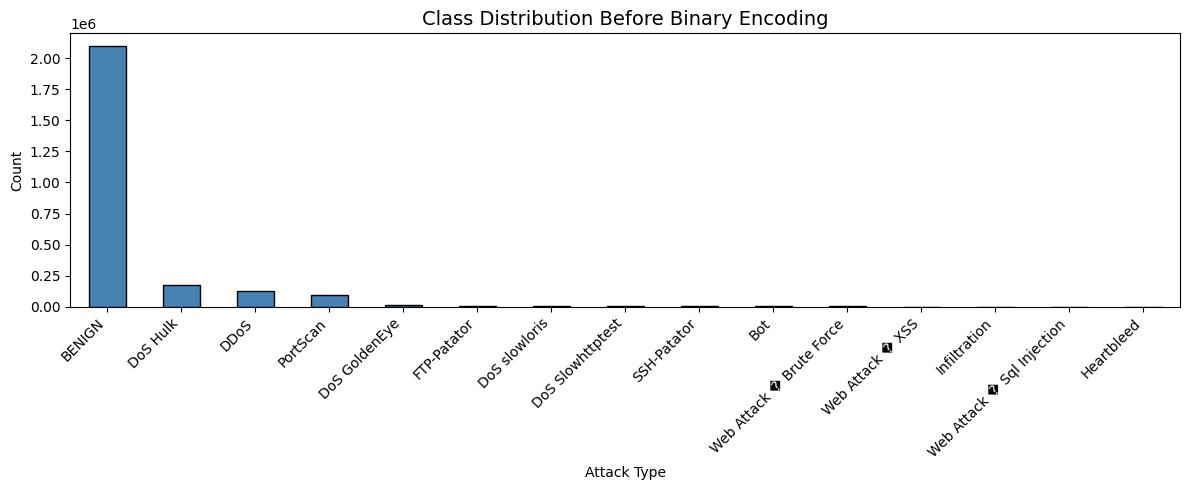

In [12]:
# Class Distribution Bar Chart 

fig, ax = plt.subplots(figsize=(12, 5))
df['Label'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Class Distribution Before Binary Encoding', fontsize=14)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'class_distribution_raw.png', dpi=150)
plt.show()

In [13]:
# Statistical summary of all numeric features

print(f'Dataset shape: {df.shape}')
print(f'Feature count: {df.shape[1] - 1}  (excluding Label)')
print(f'\nClass distribution:')
print(df['Label'].value_counts())
print()
# Full statistical summary
df.describe().T


Dataset shape: (2522362, 66)
Feature count: 65  (excluding Label)

Class distribution:
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
Destination Port,2522362.0,8.704762e+03,1.902507e+04,0.0,53.0,80.0,443.00,65535.0
Flow Duration,2522362.0,1.658132e+07,3.522426e+07,0.0,208.0,50577.0,5329717.25,119999998.0
Total Fwd Packets,2522362.0,1.027627e+01,7.941738e+02,1.0,2.0,2.0,6.00,219759.0
Total Backward Packets,2522362.0,1.156596e+01,1.056594e+03,0.0,1.0,2.0,5.00,291922.0
Total Length of Fwd Packets,2522362.0,6.115751e+02,1.058499e+04,0.0,12.0,66.0,332.00,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2522362.0,6.542300e+04,6.109712e+05,0.0,0.0,0.0,0.00,110000000.0
Idle Mean,2522362.0,9.331578e+06,2.484157e+07,0.0,0.0,0.0,0.00,120000000.0
Idle Std,2522362.0,5.654433e+05,4.872678e+06,0.0,0.0,0.0,0.00,76900000.0
Idle Max,2522362.0,9.757716e+06,2.561067e+07,0.0,0.0,0.0,0.00,120000000.0


Top 15 features by outlier percentage:
Fwd IAT Std                    23.67
Bwd Packets/s                  23.41
Total Length of Bwd Packets    22.82
Subflow Bwd Bytes              22.82
Idle Min                       22.49
Idle Max                       22.49
Idle Mean                      22.49
Active Min                     22.15
Active Max                     22.15
Active Mean                    22.15
Destination Port               21.68
Bwd IAT Total                  20.92
Bwd IAT Mean                   20.59
Fwd IAT Min                    20.35
Bwd IAT Max                    20.18
dtype: float64


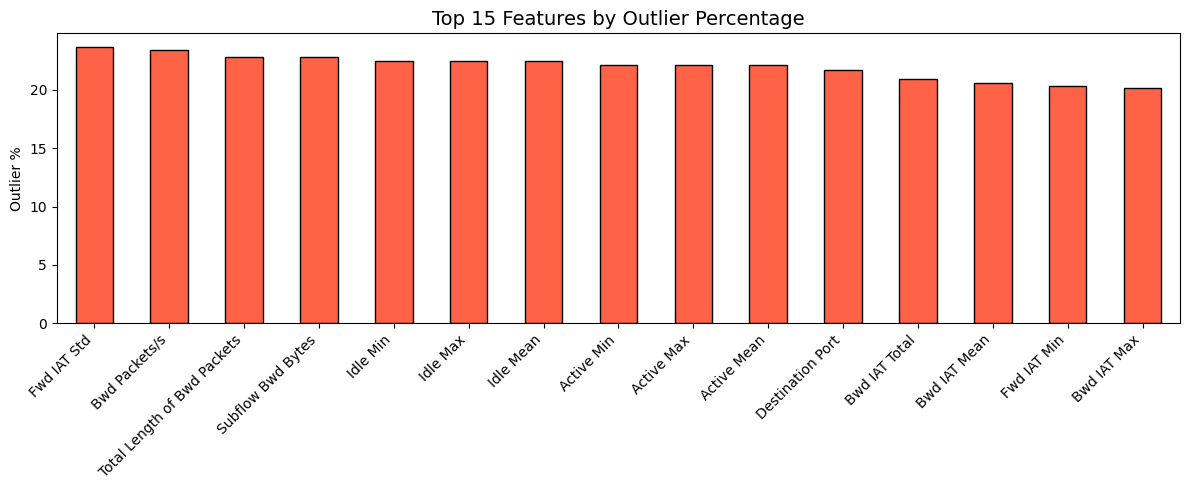

In [14]:
# Outlier Detection ( IQR Capping ) 
# The cell shows how many outliers are there in each feature that are about to be capped. 

numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_pct = (((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum() / len(df) * 100).round(2)
top_outlier_features = outlier_pct.sort_values(ascending=False).head(15)
print('Top 15 features by outlier percentage:')
print(top_outlier_features)

fig, ax = plt.subplots(figsize=(12, 5))
top_outlier_features.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
ax.set_title('Top 15 Features by Outlier Percentage', fontsize=14)
ax.set_ylabel('Outlier %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'outlier_percentages.png', dpi=150)
plt.show()

## 6. Feature Correlation exploration


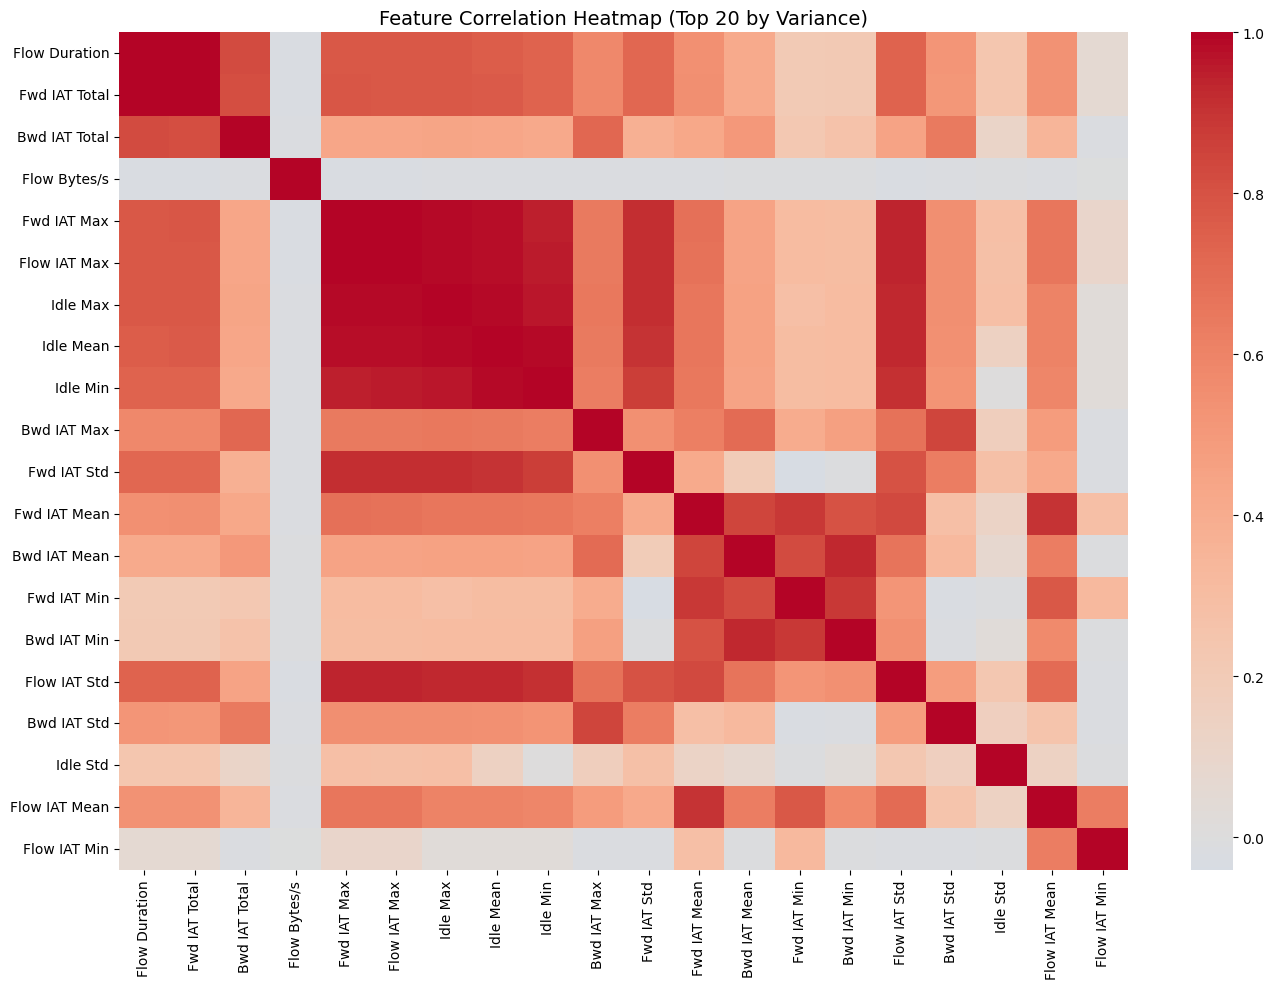

In [15]:
# Feature Correlation Heatmap (Only top 20 features)
# Use top 20 most variable features for readability

top20 = df[numeric_cols].std().nlargest(20).index
corr = df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Feature Correlation Heatmap (Top 20 by Variance)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'correlation_heatmap.png', dpi=150)
plt.show()

In [16]:
# High-Correlation Feature Removal (|r| > 0.95)
# Compute full correlation matrix on all numeric cols
corr_matrix = df[numeric_cols].corr().abs()

# Select upper triangle to avoid duplicate pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop (any column that has corr > 0.95 with another)
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
print(f'Features with |r| > 0.95 — dropping {len(high_corr_cols)} column(s):')
print(high_corr_cols)

df.drop(columns=high_corr_cols, inplace=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f'Shape after high-correlation removal: {df.shape}')

# Track shape for summary
shape_after_corr_removal = df.shape


Features with |r| > 0.95 — dropping 20 column(s):
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Std', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']
Shape after high-correlation removal: (2522362, 46)


label_corr computed successfully.
Total features: 45


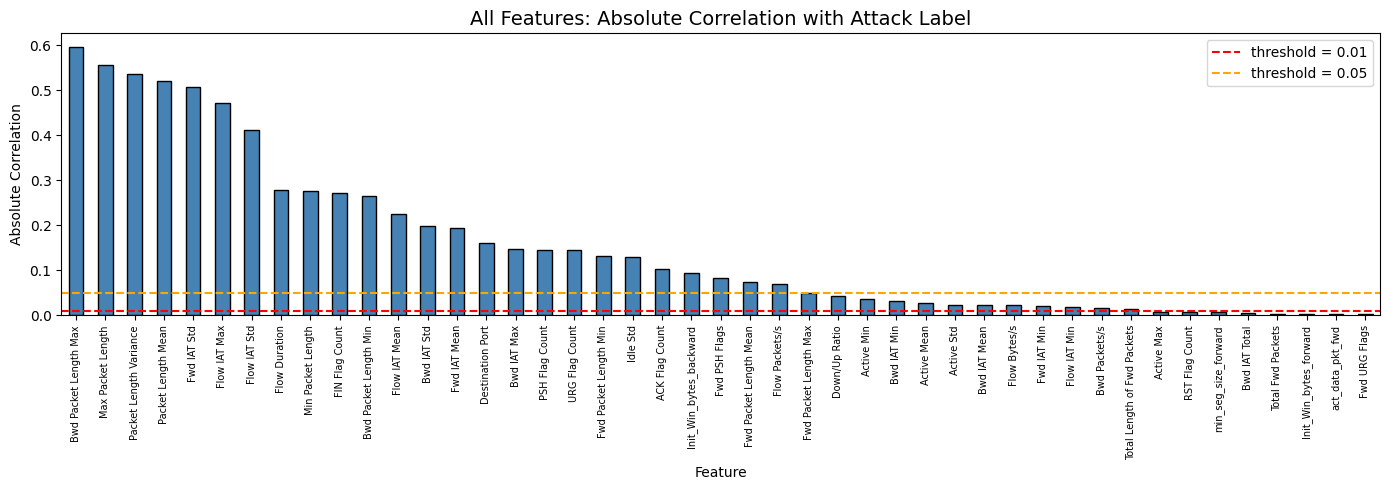

Bottom 15 features by label correlation:
Active Std                     0.022527
Bwd IAT Mean                   0.022243
Flow Bytes/s                   0.022129
Fwd IAT Min                    0.021340
Flow IAT Min                   0.018017
Bwd Packets/s                  0.016257
Total Length of Fwd Packets    0.015069
Active Max                     0.008194
RST Flag Count                 0.007434
min_seg_size_forward           0.007258
Bwd IAT Total                  0.006138
Total Fwd Packets              0.003053
Init_Win_bytes_forward         0.002748
act_data_pkt_fwd               0.002638
Fwd URG Flags                  0.002538
dtype: float64


In [17]:
# Encode label as binary (0 = BENIGN, 1 = ATTACK)
y = (df['Label'] != 'BENIGN').astype(int)
X = df.drop(columns=['Label'])

# Compute absolute correlation of each feature with the binary label
label_corr = X.corrwith(y).abs().sort_values(ascending=False)

print("label_corr computed successfully.")
print(f"Total features: {len(label_corr)}")

# Plot the full distribution of label correlations
fig, ax = plt.subplots(figsize=(14, 5))
label_corr.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('All Features: Absolute Correlation with Attack Label', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Absolute Correlation')
ax.axhline(y=0.01, color='red', linestyle='--', label='threshold = 0.01')
ax.axhline(y=0.05, color='orange', linestyle='--', label='threshold = 0.05')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'feature_label_correlation_full.png', dpi=150)
plt.show()

# Print the bottom 15 features (weakest signal)
print("Bottom 15 features by label correlation:")
print(label_corr.tail(15))


In [18]:


threshold = 0.005  # adjust this after reviewing the chart above
low_corr_cols = label_corr[label_corr < threshold].index.tolist()

print(f"Features to drop at threshold {threshold}: {low_corr_cols}")
print(f"\nTheir correlation scores:")
print(label_corr[low_corr_cols])


Features to drop at threshold 0.005: ['Total Fwd Packets', 'Init_Win_bytes_forward', 'act_data_pkt_fwd', 'Fwd URG Flags']

Their correlation scores:
Total Fwd Packets         0.003053
Init_Win_bytes_forward    0.002748
act_data_pkt_fwd          0.002638
Fwd URG Flags             0.002538
dtype: float64


## 6. Outlier Capping (IQR 1st–99th Percentile)

In [19]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(p01, p99)

print('Outlier capping complete (clipped to 1st–99th percentile).')
print(f'Shape unchanged: {df.shape}')

Outlier capping complete (clipped to 1st–99th percentile).
Shape unchanged: (2522362, 46)


## 7. Binary Label Encoding

In [20]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print('Binary label distribution:')
counts = df['Label'].value_counts()
print(counts)
print(f'\nClass ratio — BENIGN: {counts[0]/len(df)*100:.1f}%  |  Attack: {counts[1]/len(df)*100:.1f}%')

Binary label distribution:
Label
0    2096484
1     425878
Name: count, dtype: int64

Class ratio — BENIGN: 83.1%  |  Attack: 16.9%


## 8. Separate Features (X) and Label (y)

In [21]:
X = df.drop(columns=['Label'])
y = df['Label']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Number of features: {X.shape[1]}')

X shape: (2522362, 45)
y shape: (2522362,)
Number of features: 45


## 9. Normalisation (MinMaxScaler)

In [22]:
from sklearn.preprocessing import MinMaxScaler
import joblib

In [23]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Save scaler for reuse in baseline, GA, PSO, hybrid notebooks
joblib.dump(scaler, OUTPUT_DIR + 'minmax_scaler.pkl')

print('Normalisation complete. All features scaled to [0, 1].')
print(f'Scaler saved to: {OUTPUT_DIR}minmax_scaler.pkl')
print('\nSample of scaled values:')
X_scaled.describe().loc[['min', 'max']].T.head(10)

Normalisation complete. All features scaled to [0, 1].
Scaler saved to: Dataset_Cleaned/minmax_scaler.pkl

Sample of scaled values:


,min,max
Destination Port,0.0,1.0
Flow Duration,0.0,1.0
Total Fwd Packets,0.0,1.0
Total Length of Fwd Packets,0.0,1.0
Fwd Packet Length Max,0.0,1.0
Fwd Packet Length Min,0.0,1.0
Fwd Packet Length Mean,0.0,1.0
Bwd Packet Length Max,0.0,1.0
Bwd Packet Length Min,0.0,1.0
Flow Bytes/s,0.0,1.0


## 10. Train / Test Split (80/20 Stratified)

In [24]:
from sklearn.model_selection import train_test_split
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nTrain class ratio — BENIGN: {(y_train==0).sum()/len(y_train)*100:.1f}%  |  Attack: {(y_train==1).sum()/len(y_train)*100:.1f}%')
print(f'Test  class ratio — BENIGN: {(y_test==0).sum()/len(y_test)*100:.1f}%   |  Attack: {(y_test==1).sum()/len(y_test)*100:.1f}%')

X_train: (2017889, 45)  |  y_train: (2017889,)
X_test:  (504473, 45)   |  y_test:  (504473,)

Train class ratio — BENIGN: 83.1%  |  Attack: 16.9%
Test  class ratio — BENIGN: 83.1%   |  Attack: 16.9%


## 11. SMOTE — Handle Class Imbalance
> Applied **only** on training data. Test set is never touched.

In [26]:
from imblearn.over_sampling import SMOTE

In [27]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_bal).value_counts())
print(f'\nX_train shape after SMOTE: {X_train_bal.shape}')

Before SMOTE:
Label
0    1677187
1     340702
Name: count, dtype: int64

After SMOTE:
Label
0    1677187
1    1677187
Name: count, dtype: int64

X_train shape after SMOTE: (3354374, 45)


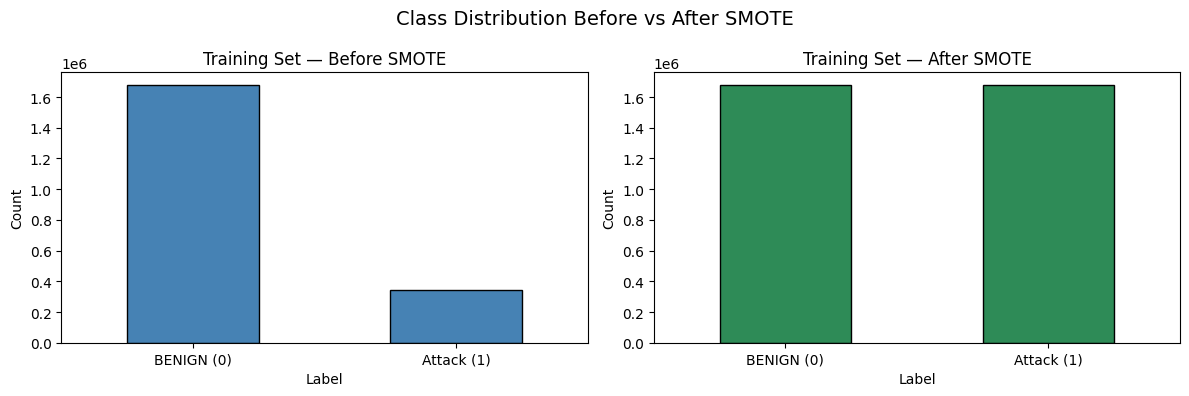

In [28]:
# Visualise class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Training Set — Before SMOTE')
axes[0].set_xticklabels(['BENIGN (0)', 'Attack (1)'], rotation=0)
axes[0].set_ylabel('Count')

pd.Series(y_train_bal).value_counts().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Training Set — After SMOTE')
axes[1].set_xticklabels(['BENIGN (0)', 'Attack (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'smote_comparison.png', dpi=150)
plt.show()

## 12. Final Preprocessing Summary

In [29]:
# Track intermediate shapes properly — no more None/NaN gaps
# Each variable must be defined by the time we reach this cell.
# shape_after_corr_removal is set in section 5b.

shape_raw           = (2830743, 79)                   # original CICIDS2017
shape_after_corr    = shape_after_corr_removal        # set in section 5b

summary = pd.DataFrame({
    'Stage': [
        'Raw dataset',
        'After duplicate row removal',
        'After Inf/NaN handling',
        'After zero-variance column removal',
        'After high-correlation removal',
        'After IQR capping',
        'After binary encoding',
        'Train set (pre-SMOTE)',
        'Train set (post-SMOTE)',
        'Test set (unchanged)'
    ],
    'Rows': [
        shape_raw[0],
        len(df) + int(df.duplicated().sum()),
        len(df),
        len(df),
        len(df),
        len(df),
        len(df),
        len(X_train),
        len(X_train_bal),
        len(X_test)
    ],
    'Features': [
        shape_raw[1] - 1,         # 78 features (excl. Label)
        shape_raw[1] - 1,
        shape_raw[1] - 1,
        df.shape[1] - 1,          # after zero-variance removal
        shape_after_corr[1] - 1,  # after high-corr removal
        shape_after_corr[1] - 1,
        shape_after_corr[1] - 1,
        X_train.shape[1],
        X_train_bal.shape[1],
        X_test.shape[1]
    ]
})
print(summary.to_string(index=False))


                             Stage    Rows  Features
                       Raw dataset 2830743        78
       After duplicate row removal 2535755        78
            After Inf/NaN handling 2522362        78
After zero-variance column removal 2522362        45
    After high-correlation removal 2522362        45
                 After IQR capping 2522362        45
             After binary encoding 2522362        45
             Train set (pre-SMOTE) 2017889        45
            Train set (post-SMOTE) 3354374        45
              Test set (unchanged)  504473        45


## 13. Save All Outputs

In [30]:
# Save raw (pre-SMOTE) training data for baseline comparison
X_train_raw_df = X_train.copy()
X_train_raw_df.to_csv(OUTPUT_DIR + 'X_train_raw.csv', index=False)
y_train.to_csv(OUTPUT_DIR + 'y_train_raw.csv', index=False)
print('Saved: X_train_raw.csv, y_train_raw.csv (pre-SMOTE)')

# Save SMOTE-balanced training data
X_train_bal_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
X_train_bal_df.to_csv(OUTPUT_DIR + 'X_train_smote.csv', index=False)
pd.Series(y_train_bal, name='Label').to_csv(OUTPUT_DIR + 'y_train_smote.csv', index=False)
print('Saved: X_train_smote.csv, y_train_smote.csv (post-SMOTE)')


Saved: X_train_raw.csv, y_train_raw.csv (pre-SMOTE)
Saved: X_train_smote.csv, y_train_smote.csv (post-SMOTE)


In [31]:
# Test data (never touched by SMOTE)
X_test.to_csv(OUTPUT_DIR + 'X_test.csv', index=False)
y_test.to_csv(OUTPUT_DIR + 'y_test.csv', index=False)
print('Saved: X_test.csv, y_test.csv')

Saved: X_test.csv, y_test.csv


In [32]:
# Full cleaned dataset (pre-split, for reference)
full_clean = X_scaled.copy()
full_clean['Label'] = y.values
full_clean.to_csv(OUTPUT_DIR + 'cleaned_data_full.csv', index=False)
print('Saved: cleaned_data_full.csv')

Saved: cleaned_data_full.csv


In [33]:
# Scaler already saved in Section 9
print('All outputs saved to:', OUTPUT_DIR)
print('\nFiles saved:')
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(OUTPUT_DIR + f) / (1024*1024)
    print(f'  {f:40s} {size:.1f} MB')

All outputs saved to: Dataset_Cleaned/

Files saved:
  X_train_raw.csv                          1114.0 MB
  y_train_smote.csv                        6.4 MB
  cleaned_data_full.csv                    1397.4 MB
  feature_label_correlation_full.png       0.1 MB
  class_distribution_raw.png               0.1 MB
  outlier_percentages.png                  0.1 MB
  X_train_smote.csv                        1885.2 MB
  correlation_heatmap.png                  0.1 MB
  smote_comparison.png                     0.0 MB
  minmax_scaler.pkl                        0.0 MB
  y_train_raw.csv                          3.8 MB
  y_test.csv                               1.0 MB
  X_test.csv                               278.6 MB
